# **🌳 캐글에서 제공하는 '공공 자전거 대여량' 데이터셋 입니다.**

🌱 각 단계에 맞추어 '**기상 상태에 따른 자전거 대여량을 예측하는 모델**'을
제작해보세요.

✔️ **[파일] - [Drive에 사본 저장]**

In [ ]:
!pip install koreanize-matplotlib

# **[단계1] 데이터 수집 및 불러오기**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
files.upload()

Saving bike_rent.csv to bike_rent (1).csv


{'bike_rent (1).csv': b'id,\xbd\xc3,\xb1\xe2\xbf\xc2,\xba\xf1,\xc7\xb3\xbc\xd3,\xbd\xc0\xb5\xb5,\xb0\xa1\xbd\xc3\xbc\xba,\xbf\xc0\xc1\xb8,pm10,pm25,\xb4\xeb\xbf\xa9\xb7\xae\r\n3,20,16.3,1,1.5,89,576,0.027,76,33,49\r\n6,13,20.1,0,1.4,48,916,0.042,73,40,159\r\n7,6,13.9,0,0.7,79,1382,0.033,32,19,26\r\n8,23,8.1,0,2.7,54,946,0.04,75,64,57\r\n9,18,29.5,0,4.8,7,2000,0.057,27,11,431\r\n13,2,13.6,0,1.7,80,1073,0.027,34,15,39\r\n14,3,10.6,0,1.5,58,1548,0.038,62,33,23\r\n16,21,16,0,6,21,1961,0.05,90,28,146\r\n19,9,13.8,0,1.9,64,1344,0.039,93,19,39\r\n20,14,17.2,0,2.1,32,1571,0.025,64,19,83\r\n21,4,5.7,0,0.6,77,1960,0.028,14,18,6\r\n22,10,15.4,0,2.7,62,1362,0.039,99,21,42\r\n24,9,14.1,0,3.2,59,1808,0.028,52,18,59\r\n27,10,9.2,0,1.9,55,462,0.023,91,84,60\r\n29,13,14,1,2.8,42,1518,0.03,49,37,5\r\n30,21,18.8,0,2.2,34,2000,0.04,32,14,217\r\n32,17,11.5,1,3,91,555,0.036,29,21,64\r\n34,18,18,1,1.9,82,685,0.044,99,42,15\r\n35,10,15.4,0,3.1,19,1225,0.032,199,18,58\r\n36,8,12.6,0,5.3,53,1576,0.014,52,40,209

In [ ]:
df = pd.read_csv('bike_rent.csv', encoding='euc-kr')
df.head()

,id,시,기온,비,풍속,습도,가시성,오존,pm10,pm25,대여량
0,3,20,16.3,1,1.5,89,576,0.027,76,33,49
1,6,13,20.1,0,1.4,48,916,0.042,73,40,159
2,7,6,13.9,0,0.7,79,1382,0.033,32,19,26
3,8,23,8.1,0,2.7,54,946,0.040,75,64,57
4,9,18,29.5,0,4.8,7,2000,0.057,27,11,431


# **[단계2] 데이터 전처리**

In [ ]:
df.describe() # 통계 정보 확인

,id,시,기온,비,풍속,습도,가시성,오존,pm10,pm25,대여량
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,831.416000,11.886000,16.829000,0.033000,2.464600,52.012000,1412.057000,0.038480,57.44900,30.244000,110.693000
std,478.707068,6.707757,5.196688,0.178726,1.386726,20.288358,575.842011,0.019338,30.79558,14.553428,83.867506
min,3.000000,0.000000,3.100000,0.000000,0.000000,7.000000,78.000000,0.003000,12.00000,9.000000,1.000000
25%,424.500000,6.000000,13.100000,0.000000,1.400000,36.000000,910.500000,0.024000,36.00000,20.000000,37.000000
50%,832.500000,12.000000,16.600000,0.000000,2.300000,51.000000,1577.000000,0.038000,52.00000,26.000000,100.000000
75%,1247.500000,18.000000,20.100000,0.000000,3.400000,68.250000,1991.000000,0.051250,70.00000,37.000000,153.000000
max,1653.000000,23.000000,30.000000,1.000000,8.000000,99.000000,2000.000000,0.106000,269.00000,90.000000,431.000000


In [ ]:
df.isnull().sum() # 결측치 확인

,0
id,0
시,0
기온,0
비,0
풍속,0
습도,0
가시성,0
오존,0
pm10,0
pm25,0


In [ ]:
df.corr() # 속성이 너무 많으니깐 상관관계부터 확인 → 대여량(종속변수) - 시, 기온, 풍속, 습도(독립변수) 로 선정

,id,시,기온,비,풍속,습도,가시성,오존,pm10,pm25,대여량
id,1.000000,-0.020196,0.001625,-0.047416,-0.032696,-0.007998,0.019403,0.027606,-0.041213,-0.014061,0.003422
시,-0.020196,1.000000,0.403481,0.045725,0.469008,-0.323675,0.197699,0.384618,-0.032258,-0.058019,0.605391
기온,0.001625,0.403481,1.000000,-0.092533,0.382022,-0.498631,0.219332,0.518350,-0.033538,-0.081834,0.608165
비,-0.047416,0.045725,-0.092533,1.000000,-0.010629,0.258833,-0.198880,-0.071489,-0.035067,0.020377,-0.163805
풍속,-0.032696,0.469008,0.382022,-0.010629,1.000000,-0.446184,0.268629,0.510398,0.013143,-0.193769,0.467537
습도,-0.007998,-0.323675,-0.498631,0.258833,-0.446184,1.000000,-0.599476,-0.412675,-0.093926,0.165688,-0.466716
가시성,0.019403,0.197699,0.219332,-0.198880,0.268629,-0.599476,1.000000,0.103975,-0.409782,-0.636572,0.333243
오존,0.027606,0.384618,0.518350,-0.071489,0.510398,-0.412675,0.103975,1.000000,0.103431,0.016705,0.446659
pm10,-0.041213,-0.032258,-0.033538,-0.035067,0.013143,-0.093926,-0.409782,0.103431,1.000000,0.487055,-0.150035
pm25,-0.014061,-0.058019,-0.081834,0.020377,-0.193769,0.165688,-0.636572,0.016705,0.487055,1.000000,-0.158201


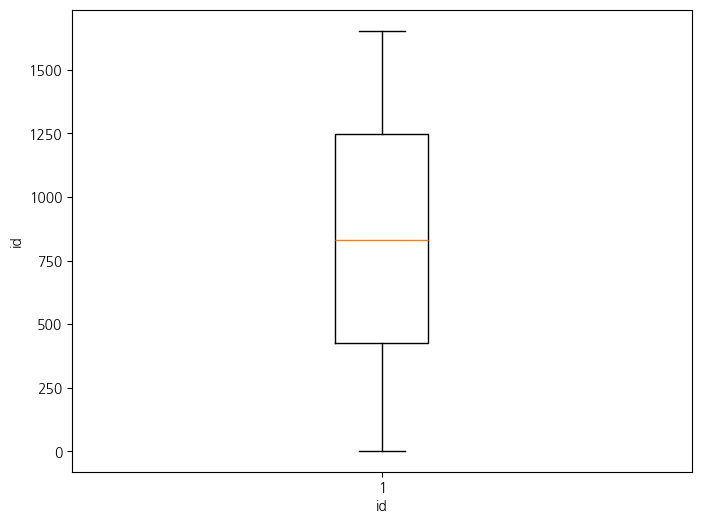

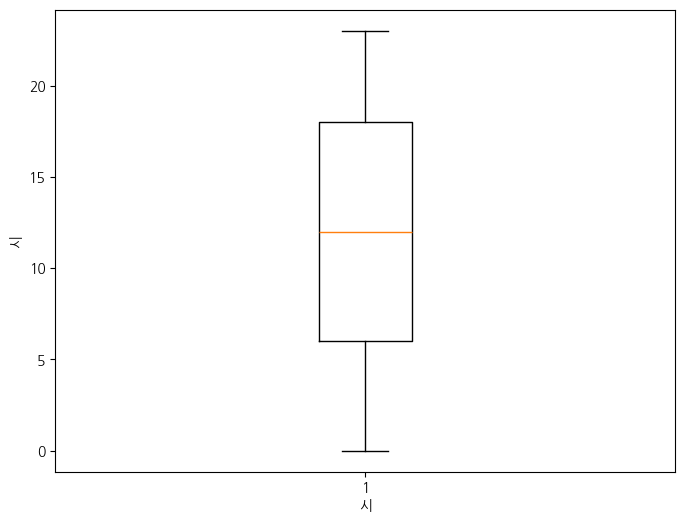

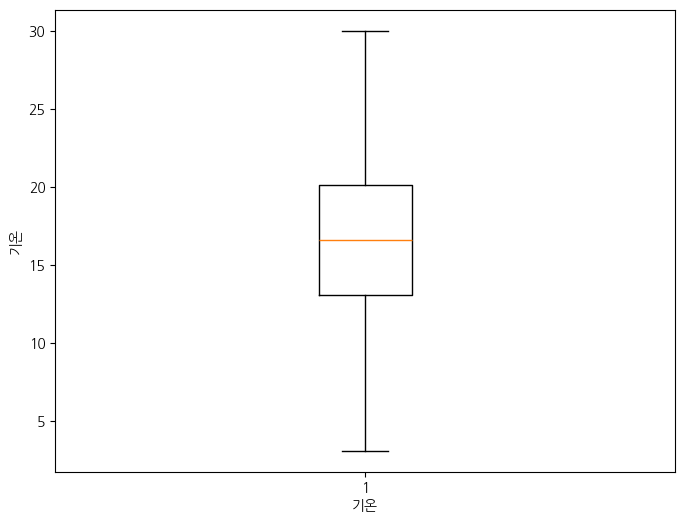

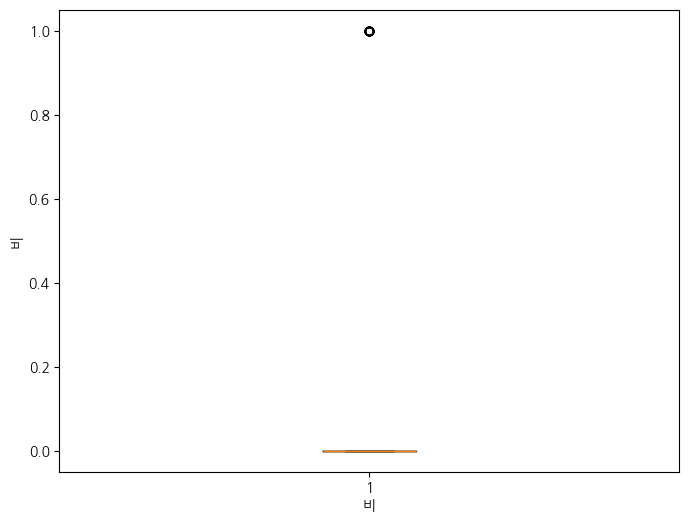

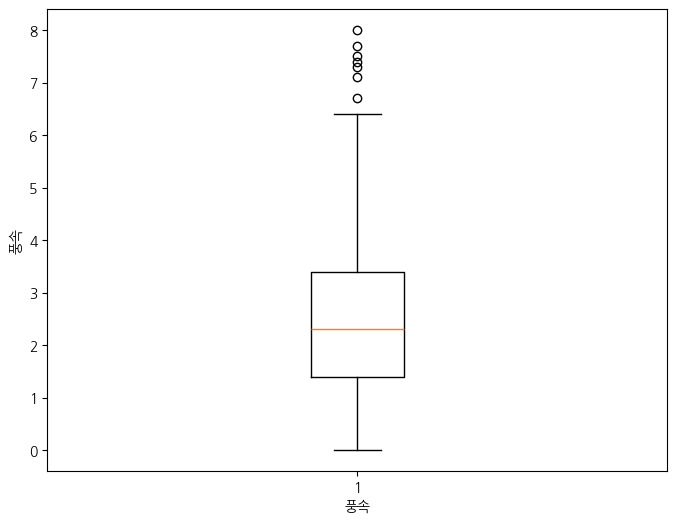

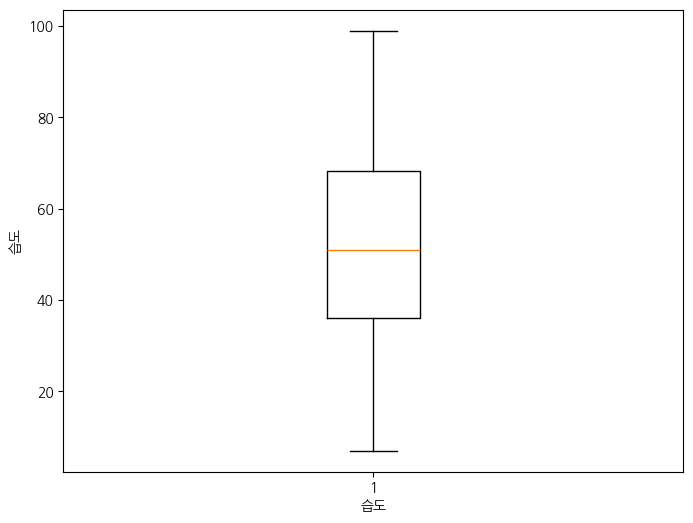

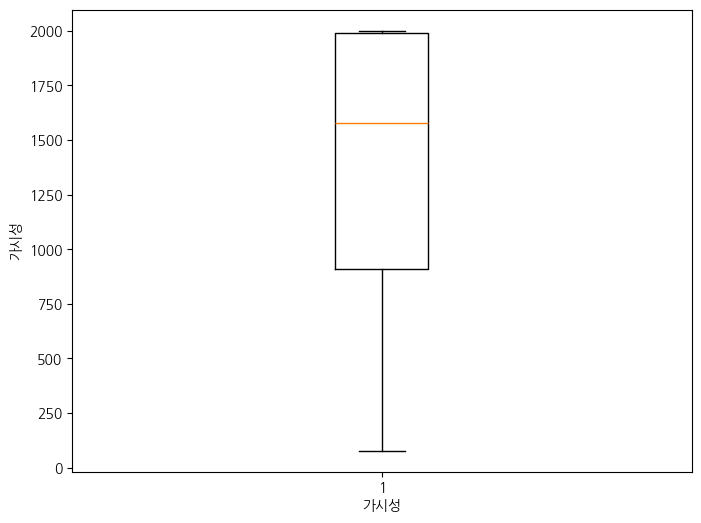

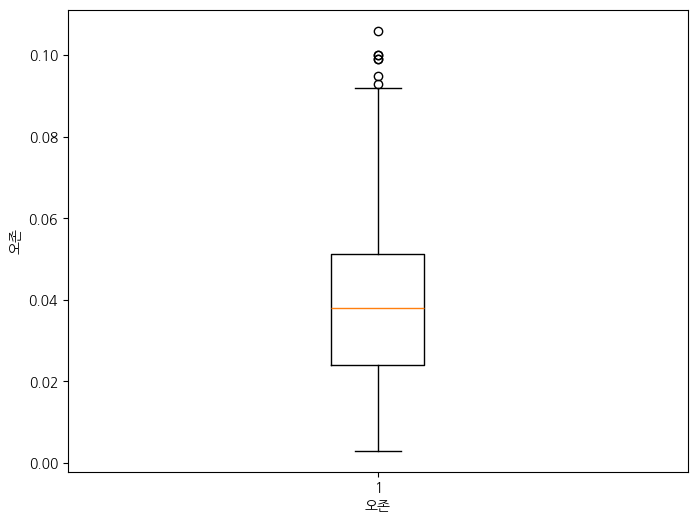

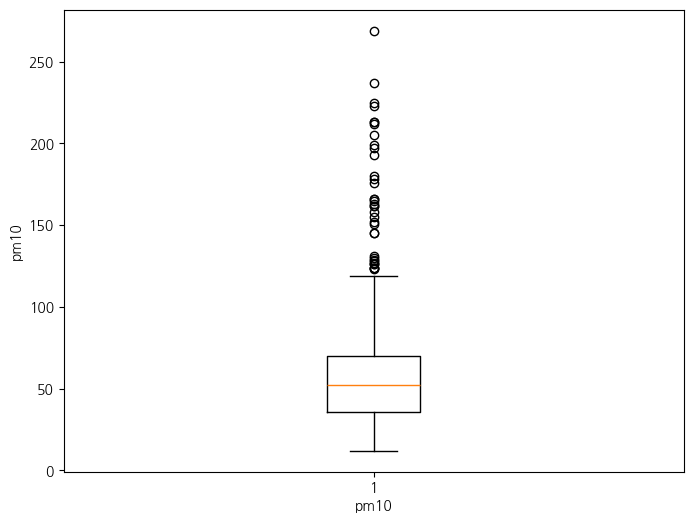

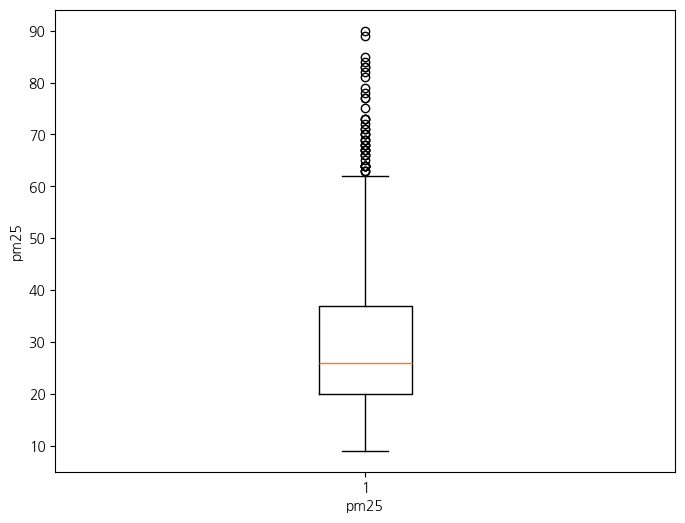

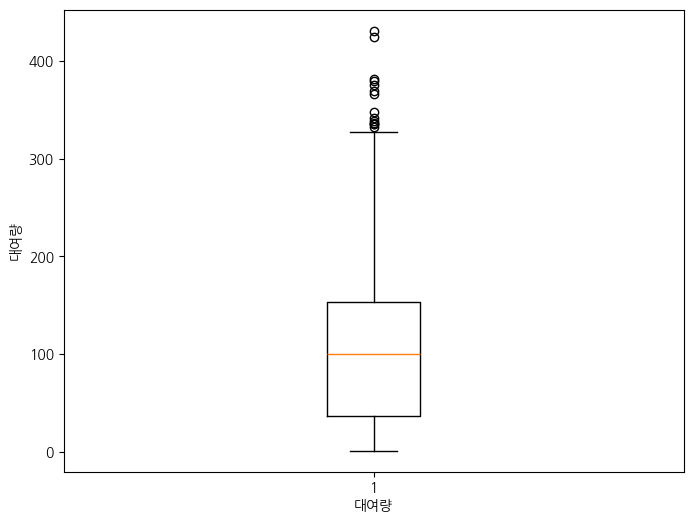

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 박스플롯 한번에 확인
for column in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[column])
    plt.xlabel(column)
    plt.ylabel(column)
    plt.show()

In [ ]:
import numpy as np

# 이상치 판단 함수
def replace_outliers_with_mean(df, column):
    # 사분위 수 표시
    Q1 = df[column].quantile(0.25) # 데이터의 하위 25% 지점
    Q3 = df[column].quantile(0.75) # 데이터의 상위 75% 지점
    IQR = Q3 - Q1 # 사분위 범위 (Q3 - Q1)

    # 일반적인 데이터 범위 계산
    lower_bound = Q1 - 1.5 * IQR # 최솟값 경계
    upper_bound = Q3 + 1.5 * IQR #최댓값 경계

    # 위의 범위를 벗어난 값들을 이상치로 판별
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)

    # 이상치가 아닌 값들만의 평균 계산
    mean_value = df[column][~outlier_mask].mean()

    # 이상치를 평균값으로 대체
    # .loc[]를 사용해 이상치가 있는 위치에 평균값을 넣어줌.
    df.loc[outlier_mask, column] = mean_value
    return df # 수정: 변경된 df를 반환하도록 다시 추가

# '풍속' 이상치 처리(평균)
df = replace_outliers_with_mean(df, '풍속')

# '대여량' 이상치 처리(평균)
df = replace_outliers_with_mean(df, '대여량')

/tmp/ipykernel_3229/822870599.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '107.09533468559837' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[outlier_mask, column] = mean_value


# **[단계3] 독립변수와 종속변수 설정하기**

In [ ]:
X = df[['시','기온','풍속','습도']]   # 독립 변수(2차원 형태)
y = df['대여량']   # 종속 변수

# **[단계4] 데이터 쪼개기**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3, random_state=0)

# **[단계5] 다중 선형회귀 모델 제작**

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(model.coef_, model.intercept_)

[ 4.23522329  4.88535082  7.03342765 -0.46551431] -18.993946418848054


# **[단계6] 모델 성능 평가**

In [ ]:
from sklearn.metrics import mean_squared_error #MSE를 계산 및 확인하기 위한 라이브러리
import numpy as np

Predicted = model.predict(X_test) #모델 예측
MSE = mean_squared_error(y_test, Predicted)
RMSE = np.sqrt(MSE) #sqrt() = 제곱근

print(f"MSE(평균제곱오차): {MSE:.2f}")
print(f"RMSE(평균제곱근오차): {RMSE:.2f}")

MSE(평균제곱오차): 3040.68
RMSE(평균제곱근오차): 55.14


In [ ]:
print('R2 score(Test data):',end=' ')
print(model.score(X_test, y_test)) # 테스트 데이터로 성능 평가하기

R2 score(Test data): 0.538245066235597


# **[단계7] 공공 자전거 대여량 예측 값을 안내하는 프로그램 모델 구현하기**

In [ ]:
data=[]
data.append(int(input('시: ')))
data.append(int(input('기온: ')))
data.append(int(input('풍속: ')))
data.append(int(input('습도: ')))

answer = model.predict([data])  # ★ 입력받은 데이터로 예측

print(f'예측 대여량은 {answer}대입니다.')

시: 9
기온: 12
풍속: 3
습도: 40
예측 대여량은 [80.22698349]대입니다.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
